# Panel Three

Here are all the images for my second panel. I am putting them together in one notebook for ease of editing, and so that I can properly see which data is being used to generate each image.

In [1]:
# Autoreloading of modules and files without restarting notebook.
%reload_ext autoreload
%autoreload 2

import pickle
import numpy as np

from tqdm import tqdm
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator

from quantities import s, ms, Quantity
from elephant.statistics import cv, isi

from rvm_analysis.utils import import_neutral_cells, import_spontaneous_cells, import_on_off_trials, import_neutral_cells_extra,combine_datasets_into_data_manager
from rvm_analysis.Spike2Tools import get_auto_correlation_freqs_with_rate
from rvm_analysis.bootstrapping import get_summary_psd_stats, bca_interval, generate_bootstrap_samples, summary_psd_stat_no_mean
from rvm_analysis.colours import get_cell_colour, colors_to_simple_names, on_off_colour_generator
from rvm_analysis.plotting_tools import add_grad_legends
from rvm_analysis.save_tools import save_in_folder
from rvm_analysis.data_loaders import read_dataset_by_protocol


#! Force the backend back to matplotlib inline (after importing viziphant).
%matplotlib inline
print(plt.get_backend())

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

module://matplotlib_inline.backend_inline


In [2]:
# Important parameters
fontsize = 7
N_bootstraps = 5000
save_path = "./Images"

# Setting some matplotlib defaults
plt.rcParams['savefig.pad_inches'] = 0
plt.rcParams["xtick.labelsize"] = fontsize
plt.rcParams["ytick.labelsize"] = fontsize

## Import the data

In [3]:
def import_from_spike_2():
    """
    Deprecated import function from spike2, in favour of using NWB files directly.
    """
    dm_on_off_trials = import_on_off_trials()
    dm_neutral = import_neutral_cells()
    dm_spontaneous = import_spontaneous_cells()
    dm_neutral_extra = import_neutral_cells_extra()

    dm_neutral_combined = combine_datasets_into_data_manager(dm_neutral,dm_neutral_extra)

    dm_combined = combine_datasets_into_data_manager(dm_neutral,dm_spontaneous,dm_neutral_extra)
    return dm_neutral_combined, dm_combined

dm_combined = read_dataset_by_protocol(['ongoing','evoked/ongoing'])

Found 66 blocks from 66 NWB files.
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
HDB_Bic09_cut_truncated.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
HDB_Bic115_cut_truncated.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
HDB_Bic12_cut_truncated.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
HDB_Bic125_cut_truncated.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
HDB_Bic42_cut_truncated.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
HDB_Bic43_cut_truncated.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
HDB_Bic47_cut_truncated.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
HDB_Bic48_cut_truncated.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
HDB_Bic51_cut_truncated.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
HDB_Bic56_cut_truncated.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
HDB_Bic57_cut_truncated.

In [4]:
for spiketrain in dm_combined.spiketrain_iterator(cell_type='All'):
    print(spiketrain.t_stop)

960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
960.0 s
3178.0 s
2742.0 s
2952.0 s
2952.0 s
3205.0 s
3368.0 s
3368.0 s
2679.0 s
2636.0 s
2890.0 s
2824.0 s
3139.0 s
2588.0 s
2881.0 s
2920.0 s
2920.0 s
3198.0 s
3198.0 s
2470.0 s
2722.0 s
2923.0 s
2758.0 s
2661.0 s
2746.0 s
2557.0 s
2557.0 s
2557.0 s
2557.0 s
2557.0 s
2123.0 s
1800.0 s
1800.0 s
2115.0 s
2098.0 s
2098.0 s
2382.0 s
2084.0 s
2052.0 s
2259.0 s
2259.0 s
2124.0 s
2055.0 s
2055.0 s
2196.0 s
2196.0 s
2022.0 s
1995.0 s
2355.0 s
2392.0 s
2392.0 s
2969.0 s
3090.0 s
2760.0 s
2720.0 s
2560.0 s
2795.0 s
2914.0 s
2897.0 s
2616.0 s
2972.0 s
2874.0 s
2915.0 s


## Example raster plot of each cell type

In [7]:


def plot_2_blocks_fancy_figure_panel_2(
        self,
        identifiers: list[str],
        rate_sampling_period=0.1 * s,
        show_rates=True,
        show_change_points=True,
        savePath="./Images",
        save=None,
        show_heart_rate=False,
        start: Quantity =0 * s,
        end: Quantity = 5000*s,
        linewidths_list=None,
        figsize=(25, 5),
        legend=True,
        ticks=None,
        show_keyboard=None,
        show_events=False,
        show_rate_title=False,
        plot_type="Trial",
        fontsize=7,
        clear_up_yaxis_ticks_rate=False,ylim_rate=None,set_yticks=None
    ):
        """
        Creates an event plot of blocks, showing the spike trains and stimuli on
        separate levels.
        `show rates`: Bool, whether to add an instantaneous rate plot underneath.
        `show_change_points: Bool, whether to a
        `heart_rate_channels`: list, the names of any heart rate channels.
        """

        blocks = list(filter(lambda x: Path(x.file_origin).stem in identifiers,self.blocks))#[self.blocks[blockIndex] for blockIndex in block_indicies]
        for block in blocks:
            print(block.file_origin)

        figure = plt.figure(figsize=figsize)
        outer: GridSpec = gridspec.GridSpec(
            len(blocks), 1, height_ratios=[1] * len(blocks), figure=figure, hspace=0.5
        )

        # make nested gridspecs
        gss = [
            gridspec.GridSpecFromSubplotSpec(
                2,
                1,
                subplot_spec=outer[i],
                hspace=0,
                wspace=0,
                height_ratios=(0.6, 0.4),
            )
            for i in range(len(blocks))
        ]

        for trial, (gs, block) in enumerate(zip(gss, blocks)):
            (
                eventtrain_list,
                colors,
                linewidths,
                labels,
                legend_colors,
                rates,
                heart_rate_index,
            ) = self.get_block_eventtrain(
                block,
                rate_sampling_period=rate_sampling_period,
                border_correction=True
            )
            if show_keyboard is not None:
                if not show_keyboard:
                    try:
                        key_idx = labels.index("keyboard")
                    except:
                        try:
                            key_idx = labels.index("Keyboard")
                        except:
                            raise ValueError("No keyboard or Keyboard channel")
                    eventtrain_list.pop(key_idx)
                    colors.pop(key_idx)
                    linewidths.pop(key_idx)
                    labels.pop(key_idx)
            if not show_events:
                for event in ["heat", "flick"]:
                    event_idx = labels.index(event)
                    eventtrain_list.pop(event_idx)
                    colors.pop(event_idx)
                    linewidths.pop(event_idx)
                    labels.pop(event_idx)
            else:
                labels[labels.index("flick")] = "behavior"
            # print(eventtrain_list,colors,linewidths,labels)

            plt.rcParams["xtick.labelsize"] = fontsize
            plt.rcParams["ytick.labelsize"] = fontsize

            def plot_eventplot_block(cell, fig, eventtrain_list, diff_colors):
                ax = plt.subplot(cell)

                ax.eventplot(
                    eventtrain_list,
                    linewidths=linewidths if not linewidths_list else linewidths_list,
                    colors=diff_colors,
                )
                ax.spines[['right', 'top']].set_visible(False)

                ax.tick_params("x", which="both", direction="in")
                # ax.set_xticks(visible=False)
                ax.tick_params(top=False, axis='x',which="both", direction="inout",labelbottom=False)

                # Create Simple Labels for the Figure
                ax.set_yticks(
                    np.arange(len(eventtrain_list)) if len(eventtrain_list) > 1 else [1.0],
                    labels=colors_to_simple_names(colors, labels),
                    fontsize=fontsize,
                )
                # legend_elements = [
                #     Line2D([0], [0], color=color[0], lw=4, label=color[1])
                #     for color in legend_colors
                # ]
                if legend:
                    add_grad_legends(legend_colors, ax, fig, fontsize=20)
                    # ax.legend(handles=legend_elements,fo ifntsize=12)s
                if ticks:
                    ax.xaxis.set_major_locator(
                        MaxNLocator(nbins=ticks, min_n_ticks=ticks)
                    )
                ax.set_xlim(float(start), float(end))

            def plot_rates_block(cell, fig, rates, trial):
                ax = plt.subplot(cell)
                ax.tick_params(top=False, which="both", direction="out")
                ax.spines[['right']].set_visible(False)

                for i, rate in enumerate(rates):
                    ax.plot(rate.times, rate, color=differentiated_colors[i],linewidth=0.5)
                ax.yaxis.set_label_coords(x=-0.06, y=0)
                ax.set_xlim(float(start), float(end))
                if clear_up_yaxis_ticks_rate:
                    ax.yaxis.set_major_locator(
                        MaxNLocator(nbins=2, min_n_ticks=2)
                    )
                if set_yticks is not None:
                    ax.set_yticks(set_yticks,set_yticks)
                if ylim_rate is not None:
                    ax.set_ylim(*ylim_rate)

            cg = on_off_colour_generator()
            differentiated_colors = cg.gen_colors_from_red_green_black(colors)
            plot_eventplot_block(gs[0], figure, eventtrain_list, differentiated_colors)
            plot_rates_block(gs[1], figure, rates, trial=trial)

        plt.tight_layout()
        if save:
            save_in_folder(
                f"Spike_rate_plot_{plot_type}", savePath, svg=True, save=save
            )
        else:
            plt.show()

CA_ongoing02a_cut_pared.smrx
CA_ongoing04b_cut_pared.smrx


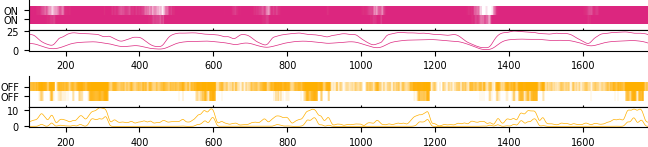

HDB_Bic42_cut_truncated.smrx


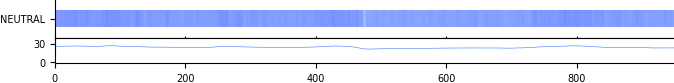

In [8]:
save_path = "./Images"
save = True

identifiers_1 = ["CA_ongoing02a_cut_pared","CA_ongoing04b_cut_pared"]
identifiers_2 = ["HDB_Bic42_cut_truncated"]

plot_2_blocks_fancy_figure_panel_2(dm_combined,identifiers_1,rate_sampling_period=0.1* s,show_change_points=False,show_rates=True,savePath=save_path,
               figsize=(8,1.66),show_events=False,start=100*s, legend=False,
               end=1778*s,plot_type='Spontaneous ON OFF',save=save,linewidths_list=None)#[0.05,0.05])

plot_2_blocks_fancy_figure_panel_2(dm_combined,identifiers_2,rate_sampling_period=0.1* s,show_change_points=False,show_rates=True,savePath=save_path,
               figsize=(8,0.83),show_events=False,start=0*s, legend=False,
               end=950*s,plot_type='Spontaneous NEUT 1',
               save=save,linewidths_list=[0.02],clear_up_yaxis_ticks_rate=True,
               ylim_rate=[-2,40],set_yticks=[0,30])

## Computing Power Spectra

In [10]:
# Get the cut spikes from the spontaneous data
cut_spikes_ON = dm_combined.get_event_windows(size=25*60*s,cell_type='ON',zero=True)
cut_spikes_OFF = dm_combined.get_event_windows(size=25*60*s,cell_type='OFF',zero=True)

min gap: 1726.4810991999998, spiketrain 23
min gap: 1777.1666439999997, spiketrain 0


In [11]:
for block in dm_combined.blocks:
    print([sp.name for sp in block.segments[0].spiketrains])

['Neutral']
['Neutral']
['Neutral']
['Neutral', 'Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral', 'Neutral']
['Neutral']
['Neutral']
['Neutral']
['ON']
['ON']
['OFF', 'ON']
['ON']
['ON', 'OFF']
['OFF']
['OFF']
['ON']
['ON']
['OFF']
['ON']
['OFF']
['OFF', 'OFF']
['OFF', 'OFF']
['ON']
['OFF']
['OFF']
['ON']
['OFF']
['OFF']
['ON', 'ON', 'ON', 'OFF', 'ON']
['OFF']
['ON', 'ON']
['ON']
['ON', 'ON']
['OFF']
['OFF']
['OFF']
['OFF', 'OFF']
['ON']
['OFF', 'ON']
['ON', 'ON']
['OFF']
['OFF']
['OFF']
['ON', 'ON']
['Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral']
['Neutral']


In [ ]:
# neuts_extra = list(dm_neutral_extra.spiketrain_iterator(cell_type='All'))

In [12]:
# neuts = list(dm_neutral.spiketrain_iterator(cell_type='All'))
all_neutral_cells = list(dm_combined.spiketrain_iterator(cell_type='Neutral'))


block_ids_ON = [train.annotations['block_id'] for train in cut_spikes_ON]
block_ids_OFF = [train.annotations['block_id'] for train in cut_spikes_OFF]
# block_ids_NEUTRAL = [train.annotations['block_id'] for train in neuts]
# block_ids_NEUTRAL_EXTRA = [train.annotations['block_id'] for train in neuts_extra]
block_ids_NEUTRAL_ALL = [train.annotations['block_id'] for train in all_neutral_cells]

# print(block_ids_NEUTRAL)
# print(block_ids_NEUTRAL_EXTRA)
print(block_ids_NEUTRAL_ALL)

[0, 1, 2, 3, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 14, 15, 16, 17, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]


In [13]:
n_welch_segs = 1
window = 'hann'
bin_size = 5*ms

fft_length= 50* len(cut_spikes_ON[0])

spectra_ON, freqs_ON, resolutions_ON = get_auto_correlation_freqs_with_rate(cut_spikes_ON,plot=False,bin_size=bin_size,
                                                                                n_largest=10,dpi=150,n_welch_segs=n_welch_segs,
                                                                                window = window, fft_length=fft_length) # want the bin size to be low so that I can oversample, and reduce aliasing.
spectra_OFF, freqs_OFF, resolutions_OFF = get_auto_correlation_freqs_with_rate(cut_spikes_OFF,plot=False,bin_size=bin_size,
                                                                                   n_largest=10,dpi=150,n_welch_segs=n_welch_segs,
                                                                                   window=window,fft_length=fft_length) # want the bin size to be low so that I can oversample, and reduce aliasing.


[2026-02-05 15:18:19,433] utils - WARNING: Correcting 29 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-02-05 15:18:25,552] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-02-05 15:18:38,252] utils - WARNING: Correcting 3 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-02-05 15:18:39,737] utils - WARNING: Correcting 5 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-02-05 15:18:40,776] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-02-05 15:18:44,934] utils - WARNING: Correcting 4 rounding errors by shifting the a

In [14]:
spectra_NEUTS_all, freqs_NEUTS_all, resolutions_NEUTS_all = get_auto_correlation_freqs_with_rate(all_neutral_cells,plot=False,bin_size=bin_size,
                                                                                n_largest=10,dpi=150,n_welch_segs=n_welch_segs,
                                                                                window = window, fft_length=fft_length)

[2026-02-05 15:19:00,326] utils - WARNING: Correcting 7 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-02-05 15:19:00,932] utils - WARNING: Correcting 2 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-02-05 15:19:01,545] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-02-05 15:19:02,771] utils - WARNING: Correcting 2 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-02-05 15:19:03,591] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-02-05 15:19:04,794] utils - WARNING: Correcting 3 rounding errors by shifting the af

## Bootstrapped confidence intervals

Instead of a percentile bootstrap, we use a Bias Corrected and Accelerated Bootstrap, also comparing a basic bootstrap. Setting `LOAD_RESULTS` to true will load the results in from "./fwhm_results_{cell_type}.pkl", to prevent re-runs of the plots taking too much time. Setting `LOAD_RESULTS` to False will run the bootstrapping.

In [16]:
LOAD_RESULTS=True

In [17]:
def compute_block_bootstrap_FWHM_individual_rats(spectra: list[tuple], block_ids, color, n_bootstrap=100,
                                 save_path="../../../../Paper 1/Supplementary",save_name="ON_FWHM",save=False,
                                 plot_Nth_bootstrap=100,plot_peaks=False):
    """
    Compute the bootstrap estimate of the FWHM of the highest magnitude peak
    in a set of normalized PSDs. Also plots the peak and its FWHM with
    confidence intervals.

    NOTE: this method boostraps calculates the statistic per rat first, then computes boostraps from it.
    NOTE: This is probably the better method!!
    """
    freqs = spectra[0][0]
    N_rats = len(spectra)
    psds = np.array([psd for _, psd in spectra])

    _, peak_frequency,_,_,_ = get_summary_psd_stats(psds,freqs)
    cutoff_freqs = (peak_frequency.magnitude*0.5, peak_frequency.magnitude*1.95) 

    peak_freqs = np.empty(N_rats)
    fwhms = np.empty(N_rats)
    for i, (_, psd) in enumerate(spectra):
        _, peak_frequency_for_spectrum, fwhm, _, _ = summary_psd_stat_no_mean(
            psd, freqs,plot=plot_peaks, cutoff_freqs=cutoff_freqs
            )
        peak_freqs[i] = peak_frequency_for_spectrum
        fwhms[i] = fwhm
    
    print(peak_freqs)

    sample_fwhm = np.mean(fwhms)
    sample_peak_frequency = np.mean(peak_freqs)
    print(sample_peak_frequency)
    sample_mean_psd = np.mean(psds, axis=0)

    unique_blocks = np.unique(block_ids)
    N_blocks = len(unique_blocks)

    rng = np.random.default_rng(seed=42)
    boot_means = np.zeros((n_bootstrap, len(freqs)))
    boot_fwhms = np.zeros(n_bootstrap)
    boot_peak_freqs = np.zeros(n_bootstrap)
    fig = plt.figure()
    for i in tqdm(range(n_bootstrap)):
        boot_blocks = rng.integers(0, N_blocks, size=N_blocks)

        boot_fwhms[i] = generate_bootstrap_samples(fwhms,block_ids,boot_blocks)[0]
        boot_means[i] = generate_bootstrap_samples(psds,block_ids,boot_blocks)[0]
        boot_peak_freqs[i] = generate_bootstrap_samples(peak_freqs,block_ids,boot_blocks)[0]

        if i % plot_Nth_bootstrap == 0:
            plt.plot(freqs,boot_means[i],linewidth=0.1)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f"Mean PSD Every {plot_Nth_bootstrap} Bootstrap")
    plt.show()


    # Jackknife stats over unique subjects/blocks
    boot_means_jackknife = np.zeros((len(block_ids), len(freqs)))
    fwhms_jackknife = np.zeros(len(block_ids))
    peak_freqs_jackknife = np.zeros(len(block_ids))
    for i, uid in enumerate(np.unique(block_ids)):
        jk_mask = block_ids != uid
        fwhms_jackknife[i] = np.mean(fwhms[jk_mask])
        boot_means_jackknife[i] = np.mean(psds[jk_mask])
        peak_freqs_jackknife[i] = np.mean(peak_freqs[jk_mask])

    fig = plt.figure()
    print("bootstrap frequency distribution - mean: ", np.mean(peak_freqs),"std: ", np.std(peak_freqs))
    plt.title("Distribution of peak Frequencies")
    plt.hist(peak_freqs)
    plt.show()

    try:
        fig = plt.figure()
        print("bootstrap frequency distribution - mean: ", np.mean(peak_freqs),"std: ", np.std(peak_freqs))
        plt.title("Distribution of sampled mean peak frequencies")
        plt.hist(boot_peak_freqs)
        plt.show()
    except Exception as e:
        print(e)

    # Confidence interval for FWHM
    # Now compute BCa interval
    fwhm_lower, fwhm_upper = bca_interval(fwhms, sample_fwhm, fwhms_jackknife,alpha=0.05)
    # fwhm_lower, fwhm_upper = basic_bootstrap_ci(fwhms,sample_fwhm,alpha=0.05) #get_confidence_bounds(fwhms)
    # fwhm_lower, fwhm_upper = get_confidence_bounds(fwhms)

    # PSD confidence interval
    psd_lower, psd_upper = bca_interval(boot_means, sample_mean_psd, boot_means_jackknife,alpha=0.05)
    # psd_lower, psd_upper = basic_bootstrap_ci(boot_means,sample_mean_psd,alpha=0.05)#get_confidence_bounds(boot_means)
    # psd_lower, psd_upper = get_confidence_bounds(boot_means)

    # Peak freq confidence interval
    peak_lower, peak_upper = bca_interval(peak_freqs, sample_peak_frequency, peak_freqs_jackknife,alpha=0.05)
    # peak_lower, peak_upper = basic_bootstrap_ci(peak_freqs,sample_peak_frequency,alpha=0.05)#get_confidence_bounds(peak_freqs)
    # peak_lower, peak_upper = get_confidence_bounds(peak_freqs)

    print(f"The FWHM is: {sample_fwhm} Hz (95% CI: {fwhm_lower} - {fwhm_upper} Hz). ")
    print(f"The peak frequency is {sample_peak_frequency} (95% CI: {peak_lower} - {peak_upper} Hz)")

    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.right'] = False

    fig = plt.figure()
    plt.title("Distribution of fwhms around peak frequency")
    plt.hist(fwhms)
    plt.show()

    return {
        "peak_freq": peak_frequency.magnitude, #!not sample_peak_frequency
        "fwhm": sample_fwhm,
        "fwhm_ci": (fwhm_lower, fwhm_upper),
        "freqs": freqs,
        "psds_bcas": (psd_lower,psd_upper),
        "peak_bcas": (peak_lower,peak_upper),
        "sample_mean_psd": sample_mean_psd
        # "fwhm_range": fwhm_freq_range
    }


In [18]:
    
def plot_bootstrap_samples(save_path,save_name,save,color,results,
                           figsize=(10,5)
                           ):
    """ Plots a Bootstrap frqeuency distribution and confidence intervals."""
    # Plotting
    freqs=results['freqs']
    psd_lower=results['psds_bcas'][0]
    psd_upper=results['psds_bcas'][1]
    peak_bcas = results['peak_bcas']
    sample_mean_psd=results['sample_mean_psd']
    peak_frequency=results['peak_freq']
    fwhm_upper = results['fwhm_ci'][1]
    fwhm_lower = results['fwhm_ci'][0]

    
    fig, ax = plt.subplots(figsize=figsize)
    ax.spines[["top","right"]].set_visible(False)
    plt.fill_between(freqs, psd_lower, psd_upper, color='lightgray', alpha=1.0, label='95% BCa CI',linewidth=0.01)
    plt.plot(freqs, sample_mean_psd, color=color, label='Average PSD',linewidth=0.6)
    # plt.axvspan(sample_left_ips_freq, sample_right_ips_freq, color='orange', alpha=0.5,
    #             label=f'mean FWHM ({(1/sample_left_ips_freq):.4f}-{(1/sample_right_ips_freq):.4f}) s')
    # plt.axvspan(peak_frequency - fwhm_upper / 2, peak_frequency + fwhm_upper / 2, color='green', alpha=0.3,
    #             label='95% CI of FWHM')
    peak_label = f'Peak Frequency: \n$T=${(1/peak_frequency): .2f} s'
    # f'Peak Frequency: {(1/peak_frequency): .2f} '
    plt.axvline(peak_frequency, color='red', linestyle='--', label=peak_label,linewidth=0.8)
    plt.xlabel('Frequency (Hz)',fontsize=7)
    plt.ylabel('Normalized PSD',fontsize=7)
    plt.legend(fontsize=7)
    plt.grid(False)
    plt.yscale('log')
    plt.xscale('log')
    # plt.tight_layout()
    save_in_folder(save_name,save_path,svg=True,dpi=300,show=True,save=save)

In [19]:
if LOAD_RESULTS:
    with open("fwhm_results_ON.pkl","rb") as f:
        results_ON = pickle.load(f)

    with open("fwhm_results_OFF.pkl","rb") as f:
        results_OFF = pickle.load(f)

    with open("fwhm_results_NEUTS.pkl","rb") as f:
        results_NEUTS = pickle.load(f)

In [20]:
if not LOAD_RESULTS:
    results_ON = compute_block_bootstrap_FWHM_individual_rats(spectra_ON,block_ids_ON,get_cell_colour(names='ON'),
                                                            n_bootstrap=N_bootstraps,
                                                            save_path=save_path,
                                            save_name="ON_FWHM",save=True,plot_Nth_bootstrap=100)

    with open("fwhm_results_ON.pkl","wb") as f:
        pickle.dump(results_ON,f)

    results_OFF = compute_block_bootstrap_FWHM_individual_rats(spectra_OFF,block_ids_OFF,get_cell_colour(names='OFF'),
                                                            n_bootstrap=N_bootstraps,
                                                            save_path=save_path,
                                            save_name="OFF_FWHM",save=True,plot_Nth_bootstrap=100,plot_peaks=False)
    
    with open("fwhm_results_OFF.pkl","wb") as f:
        pickle.dump(results_OFF,f)

    results_NEUTS = compute_block_bootstrap_FWHM_individual_rats(spectra_NEUTS_all,block_ids_NEUTRAL_ALL,
                                                                get_cell_colour(names='NEUTRAL'),
                                                                n_bootstrap=N_bootstraps,
                                                                save_path=save_path,
                                            save_name="NEUTRAL_FWHM",save=True,plot_Nth_bootstrap=100,plot_peaks=False)
    
    with open("fwhm_results_NEUTS.pkl","wb") as f:
        pickle.dump(results_NEUTS,f)

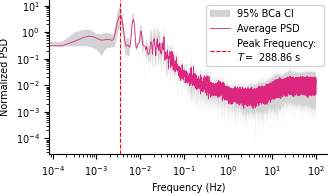

In [21]:
plot_bootstrap_samples(save_path=save_path,save_name="ON_FWHM",save=True,
                       color=get_cell_colour(names='ON'),results=results_ON,figsize=(3.6,2)
                       )

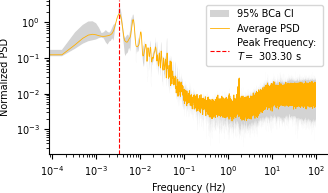

In [22]:
plot_bootstrap_samples(save_path,"OFF_FWHM",save=True,
                       color=get_cell_colour(names='OFF'),results=results_OFF, figsize=(3.6,2)
                       )

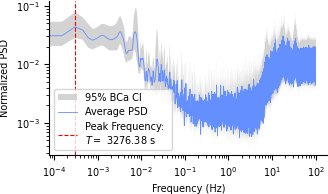

In [23]:
plot_bootstrap_samples(save_path,"NEUTRAL_FWHM",save=True,
                       color=get_cell_colour(names='NEUTRAL'),results = results_NEUTS,figsize=(3.6,2)
                       )

In [24]:
display(results_ON, results_OFF,results_NEUTS)

{'peak_freq': array(0.00346192),
 'fwhm': 0.00021321519126179175,
 'fwhm_ci': (0.0, 0.0009456669579649657),
 'freqs': array([0.00000000e+00, 1.64853281e-04, 3.29706561e-04, ...,
        9.99995054e+01, 9.99996703e+01, 9.99998351e+01]) * Hz,
 'psds_bcas': (array([0.26312589, 0.29114635, 0.29508683, ..., 0.00299675, 0.00190355,
         0.00130606]),
  array([0.31387909, 0.42887647, 1.00975275, ..., 0.00781819, 0.006443  ,
         0.0060857 ])),
 'peak_bcas': (0.002967359050445104, 0.004945598417408507),
 'sample_mean_psd': array([0.23927777, 0.30702706, 0.46880922, ..., 0.0057287 , 0.00502078,
        0.00454316])}

{'peak_freq': array(0.00329707),
 'fwhm': 0.0001234967855848445,
 'fwhm_ci': (0.0, 0.0008707784388270141),
 'freqs': array([0.00000000e+00, 1.64853281e-04, 3.29706561e-04, ...,
        9.99995054e+01, 9.99996703e+01, 9.99998351e+01]) * Hz,
 'psds_bcas': (array([0.07517478, 0.1125565 , 0.1822503 , ..., 0.00665142, 0.007102  ,
         0.00706069]),
  array([0.07908418, 0.16898167, 0.52782668, ..., 0.01193474, 0.0150006 ,
         0.00971924])),
 'peak_bcas': (0.0031322123310253873, 0.00511045169798879),
 'sample_mean_psd': array([0.07704066, 0.12312321, 0.23619519, ..., 0.01091876, 0.01028718,
        0.00965705])}

{'peak_freq': array(0.00030522),
 'fwhm': nan,
 'fwhm_ci': (0.0, 0.0),
 'freqs': array([0.00000000e+00, 1.52607684e-04, 3.05215368e-04, ...,
        9.99995422e+01, 9.99996948e+01, 9.99998474e+01]) * Hz,
 'psds_bcas': (array([0.01371094, 0.02068757, 0.02866024, ..., 0.00519111, 0.00581284,
         0.0064371 ]),
  array([0.03208553, 0.05332044, 0.07795947, ..., 0.010317  , 0.0129849 ,
         0.01590104])),
 'peak_bcas': (0.00030521536759375834, 0.00030521536759375834),
 'sample_mean_psd': array([0.01981059, 0.03081653, 0.04362643, ..., 0.00700331, 0.00823133,
        0.00966327])}

## Cell ISI CV plot

In [26]:
def plot_scatter_for_descriptors_with_groups_panel_2(
    grouped_spiketrains,
    filename: str,
    desc_1: Callable,
    desc_2: Callable,
    xlabel: str,
    ylabel: str,
    log_x=False,
    log_y=False,
    base_path="../Analysis_plots",
    figsize=(5, 5),
    markersize=6,
    svg=False,
    save=False, fontsize=7,
):
    legend_tags = {}
    fig, ax = plt.subplots(figsize=figsize)
    ax.spines[['right', 'top']].set_visible(False)

    for i, (key, spiketrains) in enumerate(grouped_spiketrains.items()):

        descriptors = [
            (
                desc_1(spiketrain),
                desc_2(spiketrain),
                get_cell_colour(spiketrains=spiketrain),
                spiketrain.name,
            )
            for spiketrain in spiketrains
        ]
        means, cvs, colors, names = zip(*descriptors)
        plt.scatter(means, cvs, color=colors[0], s=markersize)
        legend_tags[key] = colors[0]
    plt.xlabel(xlabel, fontsize=fontsize)
    plt.ylabel(ylabel, fontsize=fontsize)
    if log_x:
        plt.xscale("log")
    if log_y:
        plt.yscale("log")

    plt.tight_layout(rect=(0.0, 0.03, 1.0, 0.95))
    save_in_folder(filename, basePath=base_path, svg=svg, save=save)

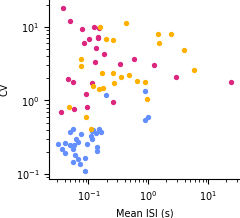

In [27]:

grouped_spiketrains = {}
grouped_spiketrains['NEUTRAL'] = list(dm_combined.spiketrain_iterator(cell_type='Neutral'))
grouped_spiketrains['ON'] = list(dm_combined.spiketrain_iterator(cell_type='ON'))
grouped_spiketrains['OFF'] = list(dm_combined.spiketrain_iterator(cell_type='OFF'))

plot_scatter_for_descriptors_with_groups_panel_2(
    grouped_spiketrains, "grouped_spiketrains_cv_plot",lambda x: np.mean(isi(x)),
                             lambda x: cv(isi(x).magnitude), #type: ignore
                             "Mean ISI (s)","CV", base_path=save_path, svg=True,
                             figsize=(2.7,2.7),log_y=True,log_x=True,
                             markersize=8,save=True
)